In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
x=dataset.iloc[:,[3,4]].values
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [4]:
from sklearn.cluster import MeanShift
clusmodel=MeanShift(bandwidth=1.5,max_iter=200)
label=clusmodel.fit_predict(x)
label

array([154, 153, 152,  32, 151,  32, 150, 149, 148, 147,  12, 146,  12,
       145,  12, 144, 143, 142, 141, 140, 139,  31, 138,  31, 137, 135,
        30, 136,  30, 134, 133, 132, 131, 128, 130, 129, 127, 126, 125,
       124,  29, 123,  29, 121, 122, 120, 118, 119,  28,  28, 117,  27,
       115,  27,  26, 116, 114,  26,  11, 113,  25,  25,  11,  10,  11,
        10,  11,  24,  10,  24,  23, 112, 111,  23,   9,   7,   8,   9,
         8,  22,   8,   7,  22, 110, 109,   9, 107, 108, 105, 106, 104,
         6,   5,   6,   6, 102, 103,   5,   0,   5,   0,   4, 101,   3,
         3,   0, 100,  21,   2,   4,  99,   3,   2,  21,  98,  97,   2,
        96,  94,  20,  20,  95,  93,  92,  91,  90,  18,  87,  88,  19,
        89,  19,  18,  86,  85,  83,  84,  17,  82,  17,  81,  80,  79,
        78,  77,  75,  76,  16,  73,   1,  14,   1,  74,  72,  14,   1,
        15,  71,  15,  16,  70,  69,  68,  67,  66,  65,  64,  63,  61,
        60,  13,  59,  62,  58,  13,  55,  57,  56,  54,  53,  5

In [5]:
supervised=dataset
supervised["cluster_group"]=label
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,154
1,2,Male,21,15,81,153
2,3,Female,20,16,6,152
3,4,Female,23,16,77,32
4,5,Female,31,17,40,151
...,...,...,...,...,...,...
195,196,Female,35,120,79,37
196,197,Female,45,126,28,36
197,198,Male,32,126,74,35
198,199,Male,32,137,18,34


In [6]:
supervised.to_csv("Meanshift_cluster.csv",index=False)
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,154
1,2,Male,21,15,81,153
2,3,Female,20,16,6,152
3,4,Female,23,16,77,32
4,5,Female,31,17,40,151
...,...,...,...,...,...,...
195,196,Female,35,120,79,37
196,197,Female,45,126,28,36
197,198,Male,32,126,74,35
198,199,Male,32,137,18,34


C:\Anaconda3\envs\ai\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


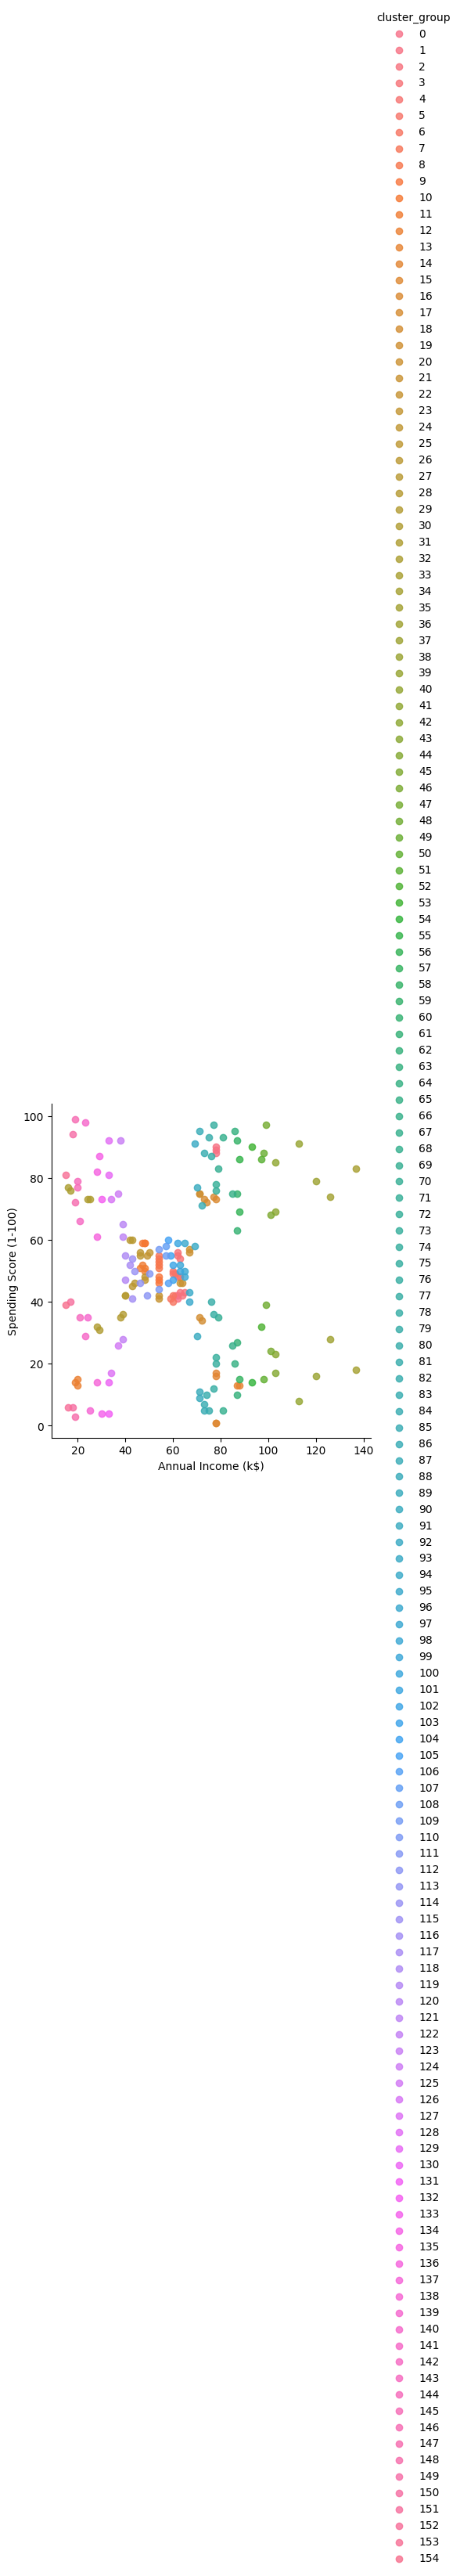

In [7]:
import seaborn as sns
facet=sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],fit_reg=False,legend=True,legend_out=True)
facet

In [8]:
from sklearn.metrics import silhouette_score
silhouette_score(x,label)

np.float64(0.2233285978361716)